<a href="https://colab.research.google.com/github/nikolas-joyce/Event_Time/blob/main/Event_Time_Experiments_1_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install yfinance once per session
!pip install yfinance --quiet

# Import libraries
import yfinance as yf
import pandas as pd

# Define the ticker symbols and date range
ticker_symbols = ['SPY', 'QQQ', 'DIA', 'GOOG', 'AAPL']  # SPY is SPDR S&P 500 ETF Trust, QQQ is Invesco QQQ Trust, DIA is SPDR Dow Jones Industrial Average ETF Trust, GOOG is Alphabet Inc., AAPL is Apple Inc.
start_date = '2010-01-01'
end_date = '2026-11-25'

# Download historical data for all tickers with adjusted close prices
data = yf.download(ticker_symbols, start=start_date, end=end_date, progress=True, auto_adjust=True, group_by='ticker', threads=True)

# Extract Close price for each ticker into a single DataFrame
close_prices = pd.DataFrame({ticker: data[ticker]['Close'] for ticker in ticker_symbols})

# Display the first few rows of Close price data
(close_prices.head())


[*********************100%***********************]  5 of 5 completed


,SPY,QQQ,DIA,GOOG,AAPL
Date,,,,,
2010-01-04,85.279182,40.393578,75.132179,15.504140,6.418382
2010-01-05,85.504951,40.393578,75.011261,15.435865,6.429479
2010-01-06,85.565125,40.149910,75.061020,15.046746,6.327210
2010-01-07,85.926323,40.176029,75.331207,14.696465,6.315512
2010-01-08,86.212280,40.506702,75.452141,14.892386,6.357501


<Axes: xlabel='Date'>

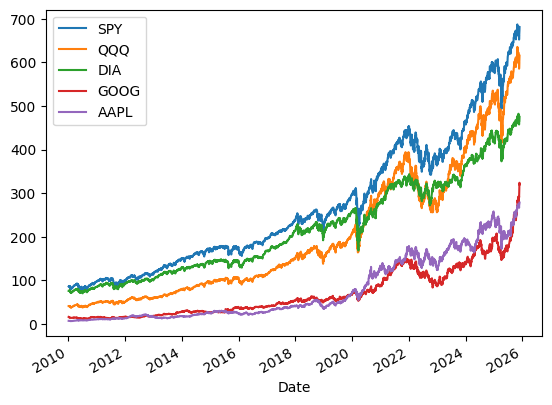

In [2]:
close_prices.plot()

In [3]:
import numpy as np

# Parameters
k = 0.5  # breakout multiplier constant
window = 20  # lookback window for volatility calculation

# Assuming 'close_prices' is your DataFrame with Close prices for multiple tickers

def volatility_breakout_strategy(df_close, k=0.5, window=20):
    """
    Volatility Breakout Strategy:
    Buy if today's close breaks above yesterday's close + k * yesterday's volatility range
    Sell signal or no position otherwise

    Args:
        df_close: DataFrame with Close prices indexed by date, columns = tickers
        k: multiplier for volatility range
        window: window size for volatility calc

    Returns:
        signals: DataFrame of boolean buy signals for each ticker and date
    """
    # Calculate daily returns volatility as rolling std of pct change
    vol = df_close.pct_change().rolling(window=window).std()

    # Calculate breakout threshold = yesterday's close + k * yesterday's volatility * yesterday's close
    shifted_close = df_close.shift(1)
    breakout_threshold = shifted_close * (1 + k * vol.shift(1))

    # Define buy signals when today's close > breakout threshold
    signals = df_close > breakout_threshold

    return signals

# Example usage with previously downloaded close_prices DataFrame
buy_signals = volatility_breakout_strategy(close_prices, k=k, window=window)

(buy_signals.tail())


,SPY,QQQ,DIA,GOOG,AAPL
Date,,,,,
2025-11-20,False,False,False,False,False
2025-11-21,True,True,True,True,True
2025-11-24,True,True,True,True,True
2025-11-25,True,False,True,True,False
2025-11-26,True,True,True,False,False


/tmp/ipython-input-3424477867.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  positions[ticker] = buy_signals[ticker].shift(1).fillna(False).astype(int)
/tmp/ipython-input-3424477867.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  positions[ticker] = buy_signals[ticker].shift(1).fillna(False).astype(int)
/tmp/ipython-input-3424477867.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, s

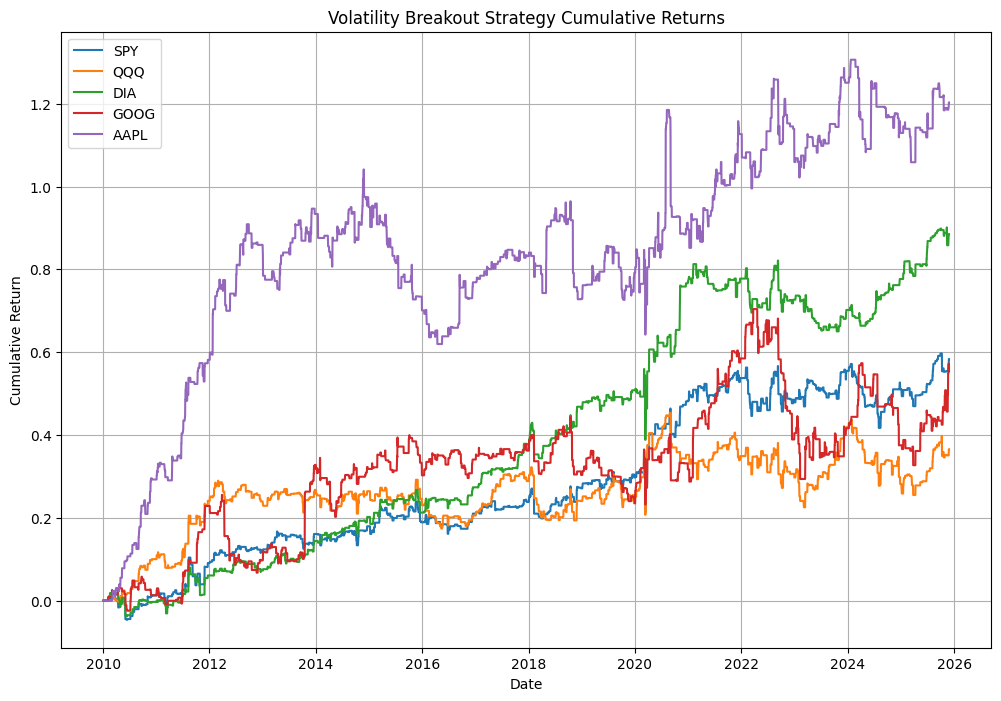

In [4]:
# Backtest volatility breakout strategy performance

initial_capital = 100000  # Starting portfolio value in USD
positions = pd.DataFrame(index=close_prices.index).fillna(0)  # To hold position sizes (units)
portfolio = pd.DataFrame(index=close_prices.index)  # To track portfolio value over time

# Generate buy signals using the volatility breakout function from step 3
buy_signals = volatility_breakout_strategy(close_prices, k=1.1, window=20)

# Assume we buy 1 unit of the asset when signal is True and hold until next signal
for ticker in buy_signals.columns:
    positions[ticker] = buy_signals[ticker].shift(1).fillna(False).astype(int)

# Calculate daily portfolio value = sum of position units * Close prices
portfolio['holdings'] = (positions * close_prices).sum(axis=1)

# Assume all capital is initially cash
portfolio['cash'] = initial_capital - (positions.diff().fillna(0) * close_prices).sum(axis=1).cumsum()

# Total portfolio value = holdings + cash
portfolio['total'] = portfolio['holdings'] + portfolio['cash']

# Calculate returns
portfolio['returns'] = portfolio['total'].pct_change()

import matplotlib.pyplot as plt

# Calculate daily strategy returns based on the portfolio total value change
portfolio['strategy_returns'] = portfolio['total'].pct_change().fillna(0)

# Calculate cumulative returns for each ticker based on buy signals and close prices
cumulative_returns = pd.DataFrame(index=close_prices.index)

for ticker in close_prices.columns:
    # Calculate daily returns when holding position (shift signals for execution delay)
    daily_returns = close_prices[ticker].pct_change().shift(-1).fillna(0)
    strategy_daily_returns = daily_returns * buy_signals[ticker].shift(1).fillna(False).astype(int)

    # Calculate cumulative returns over time
    cumulative_returns[ticker] = (1 + strategy_daily_returns).cumprod() - 1

# Plot cumulative returns for all tickers
plt.figure(figsize=(12, 8))
for ticker in cumulative_returns.columns:
    plt.plot(cumulative_returns[ticker], label=ticker)

plt.title('Volatility Breakout Strategy Cumulative Returns')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.show()



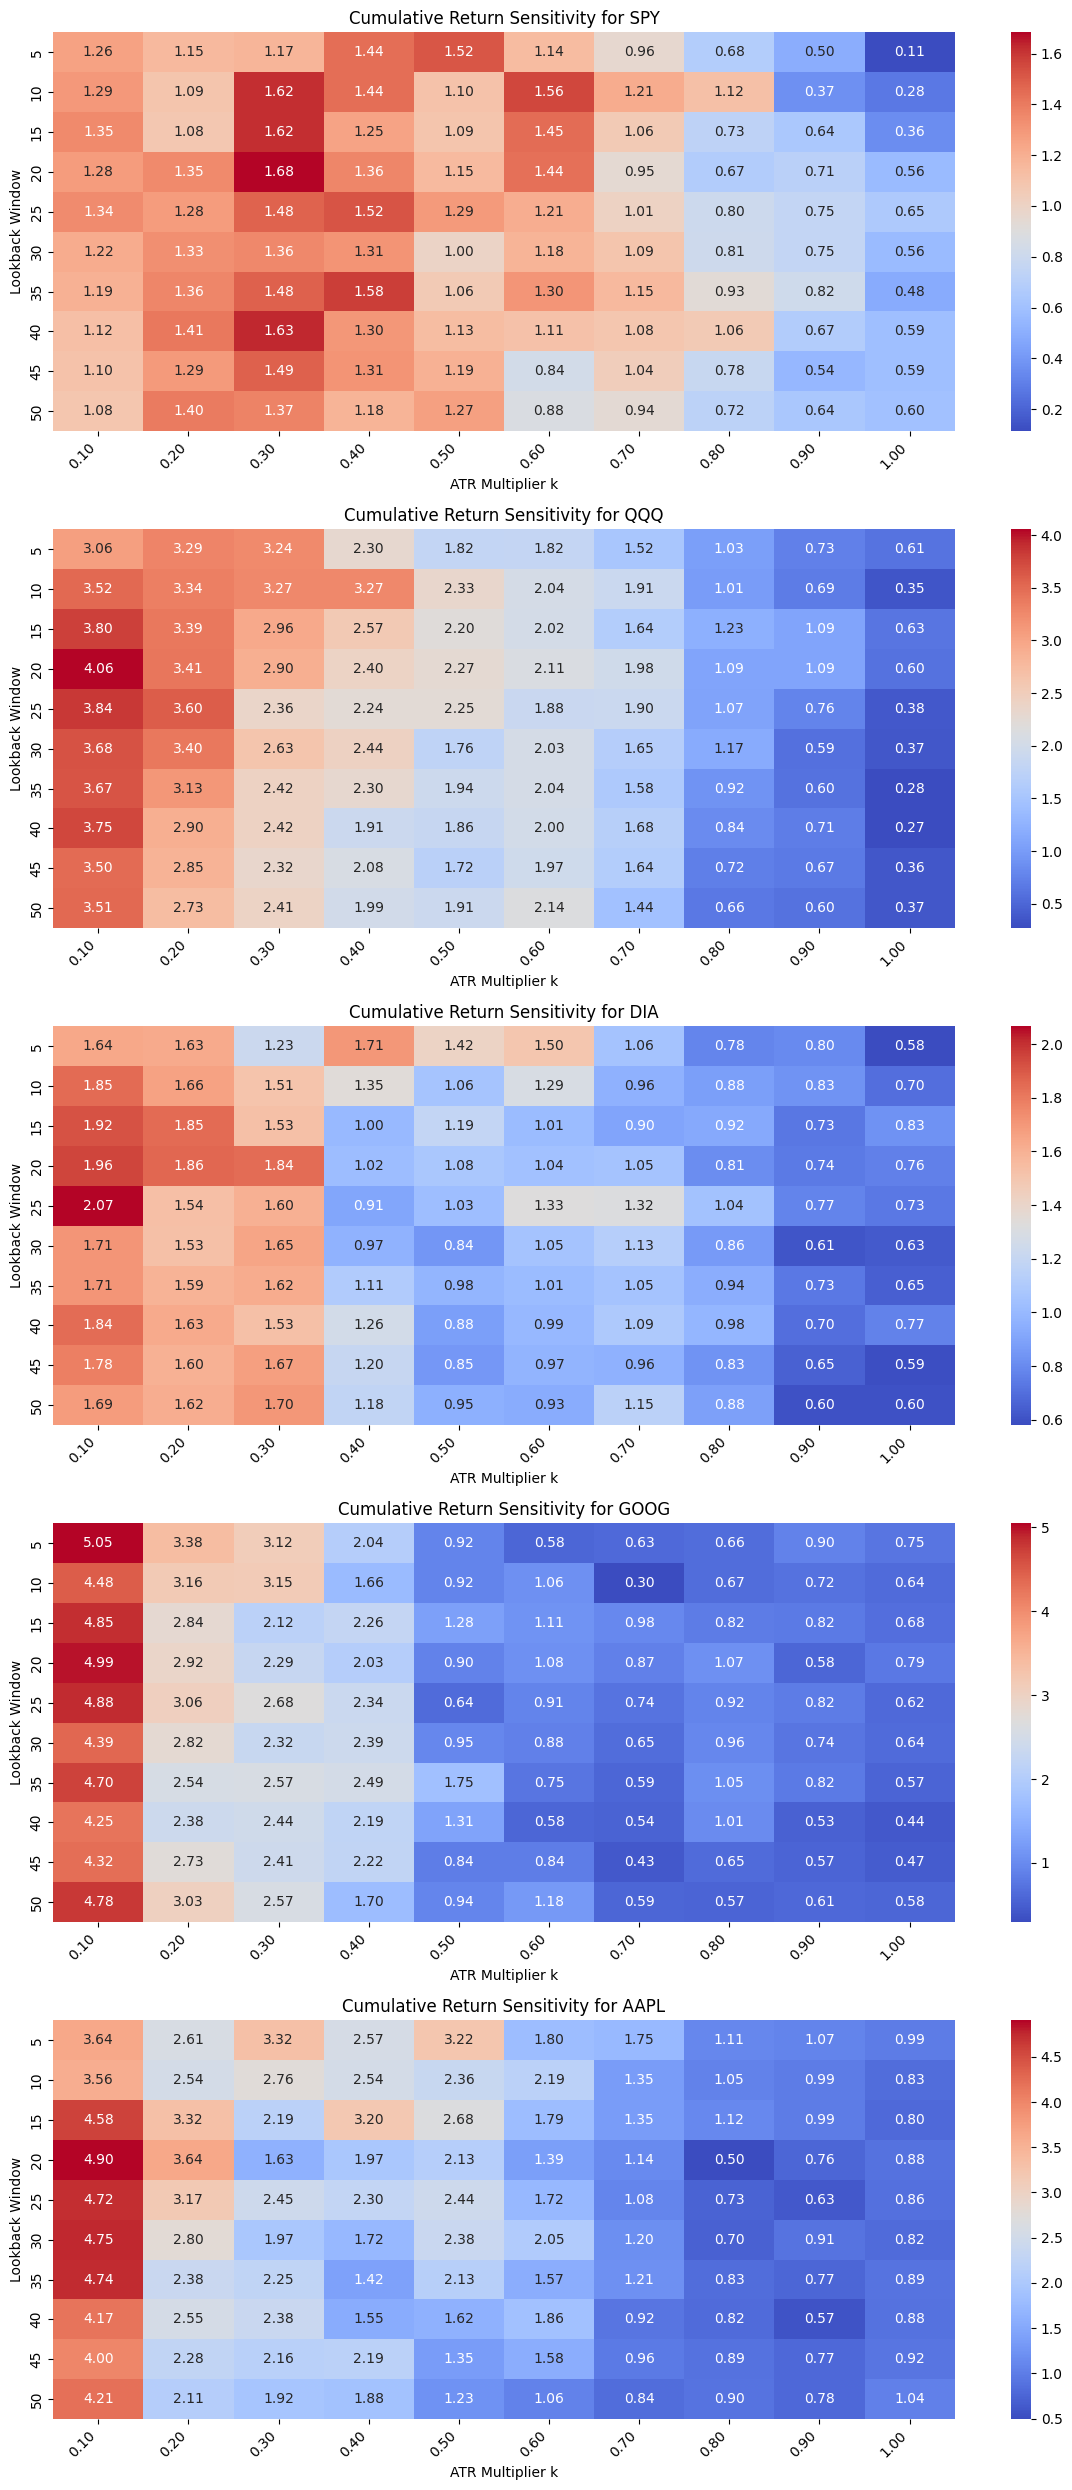

In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Suppress pandas FutureWarning for downcasting
pd.set_option('future.no_silent_downcasting', True)

# Assume 'close_prices' DataFrame and 'volatility_breakout_strategy' function are defined

tickers = close_prices.columns.tolist()
lookback_windows = range(5, 51, 5)  # Lookback periods: 5, 10, ..., 50 days
k_factors = np.arange(0.1, 1.1, 0.1)  # ATR multipliers: 0.1 to 1.0

fig, axes = plt.subplots(nrows=len(tickers), ncols=1, figsize=(12, 5 * len(tickers)))

if len(tickers) == 1:
    axes = [axes]  # ensure axes is iterable

for ax, ticker in zip(axes, tickers):
    pnl_matrix = pd.DataFrame(index=lookback_windows, columns=k_factors)

    for window in lookback_windows:
        for k in k_factors:
            # Generate breakout signals for the ticker with parameters
            signals = volatility_breakout_strategy(close_prices[[ticker]], k=k, window=window)

            # Calculate daily returns shifted for execution delay
            daily_returns = close_prices[ticker].pct_change().shift(-1).fillna(0)
            strategy_returns = daily_returns * signals[ticker].shift(1).fillna(False).astype(int)

            # Calculate cumulative return
            cumulative_return = (1 + strategy_returns).prod() - 1
            pnl_matrix.at[window, k] = cumulative_return

    pnl_matrix = pnl_matrix.astype(float)

    # Plot heatmap with annotated cumulative returns
    sns.heatmap(pnl_matrix, ax=ax, cmap='coolwarm', annot=True, fmt=".2f")

    ax.set_title(f'Cumulative Return Sensitivity for {ticker}')
    ax.set_xlabel('ATR Multiplier k')
    ax.set_ylabel('Lookback Window')

    # Rotate x-axis labels 45 degrees, format numbers to two decimals, align right
    labels = [f"{x:.2f}" for x in pnl_matrix.columns]
    ax.set_xticklabels(labels, rotation=45, ha='right')

plt.tight_layout()
plt.show()


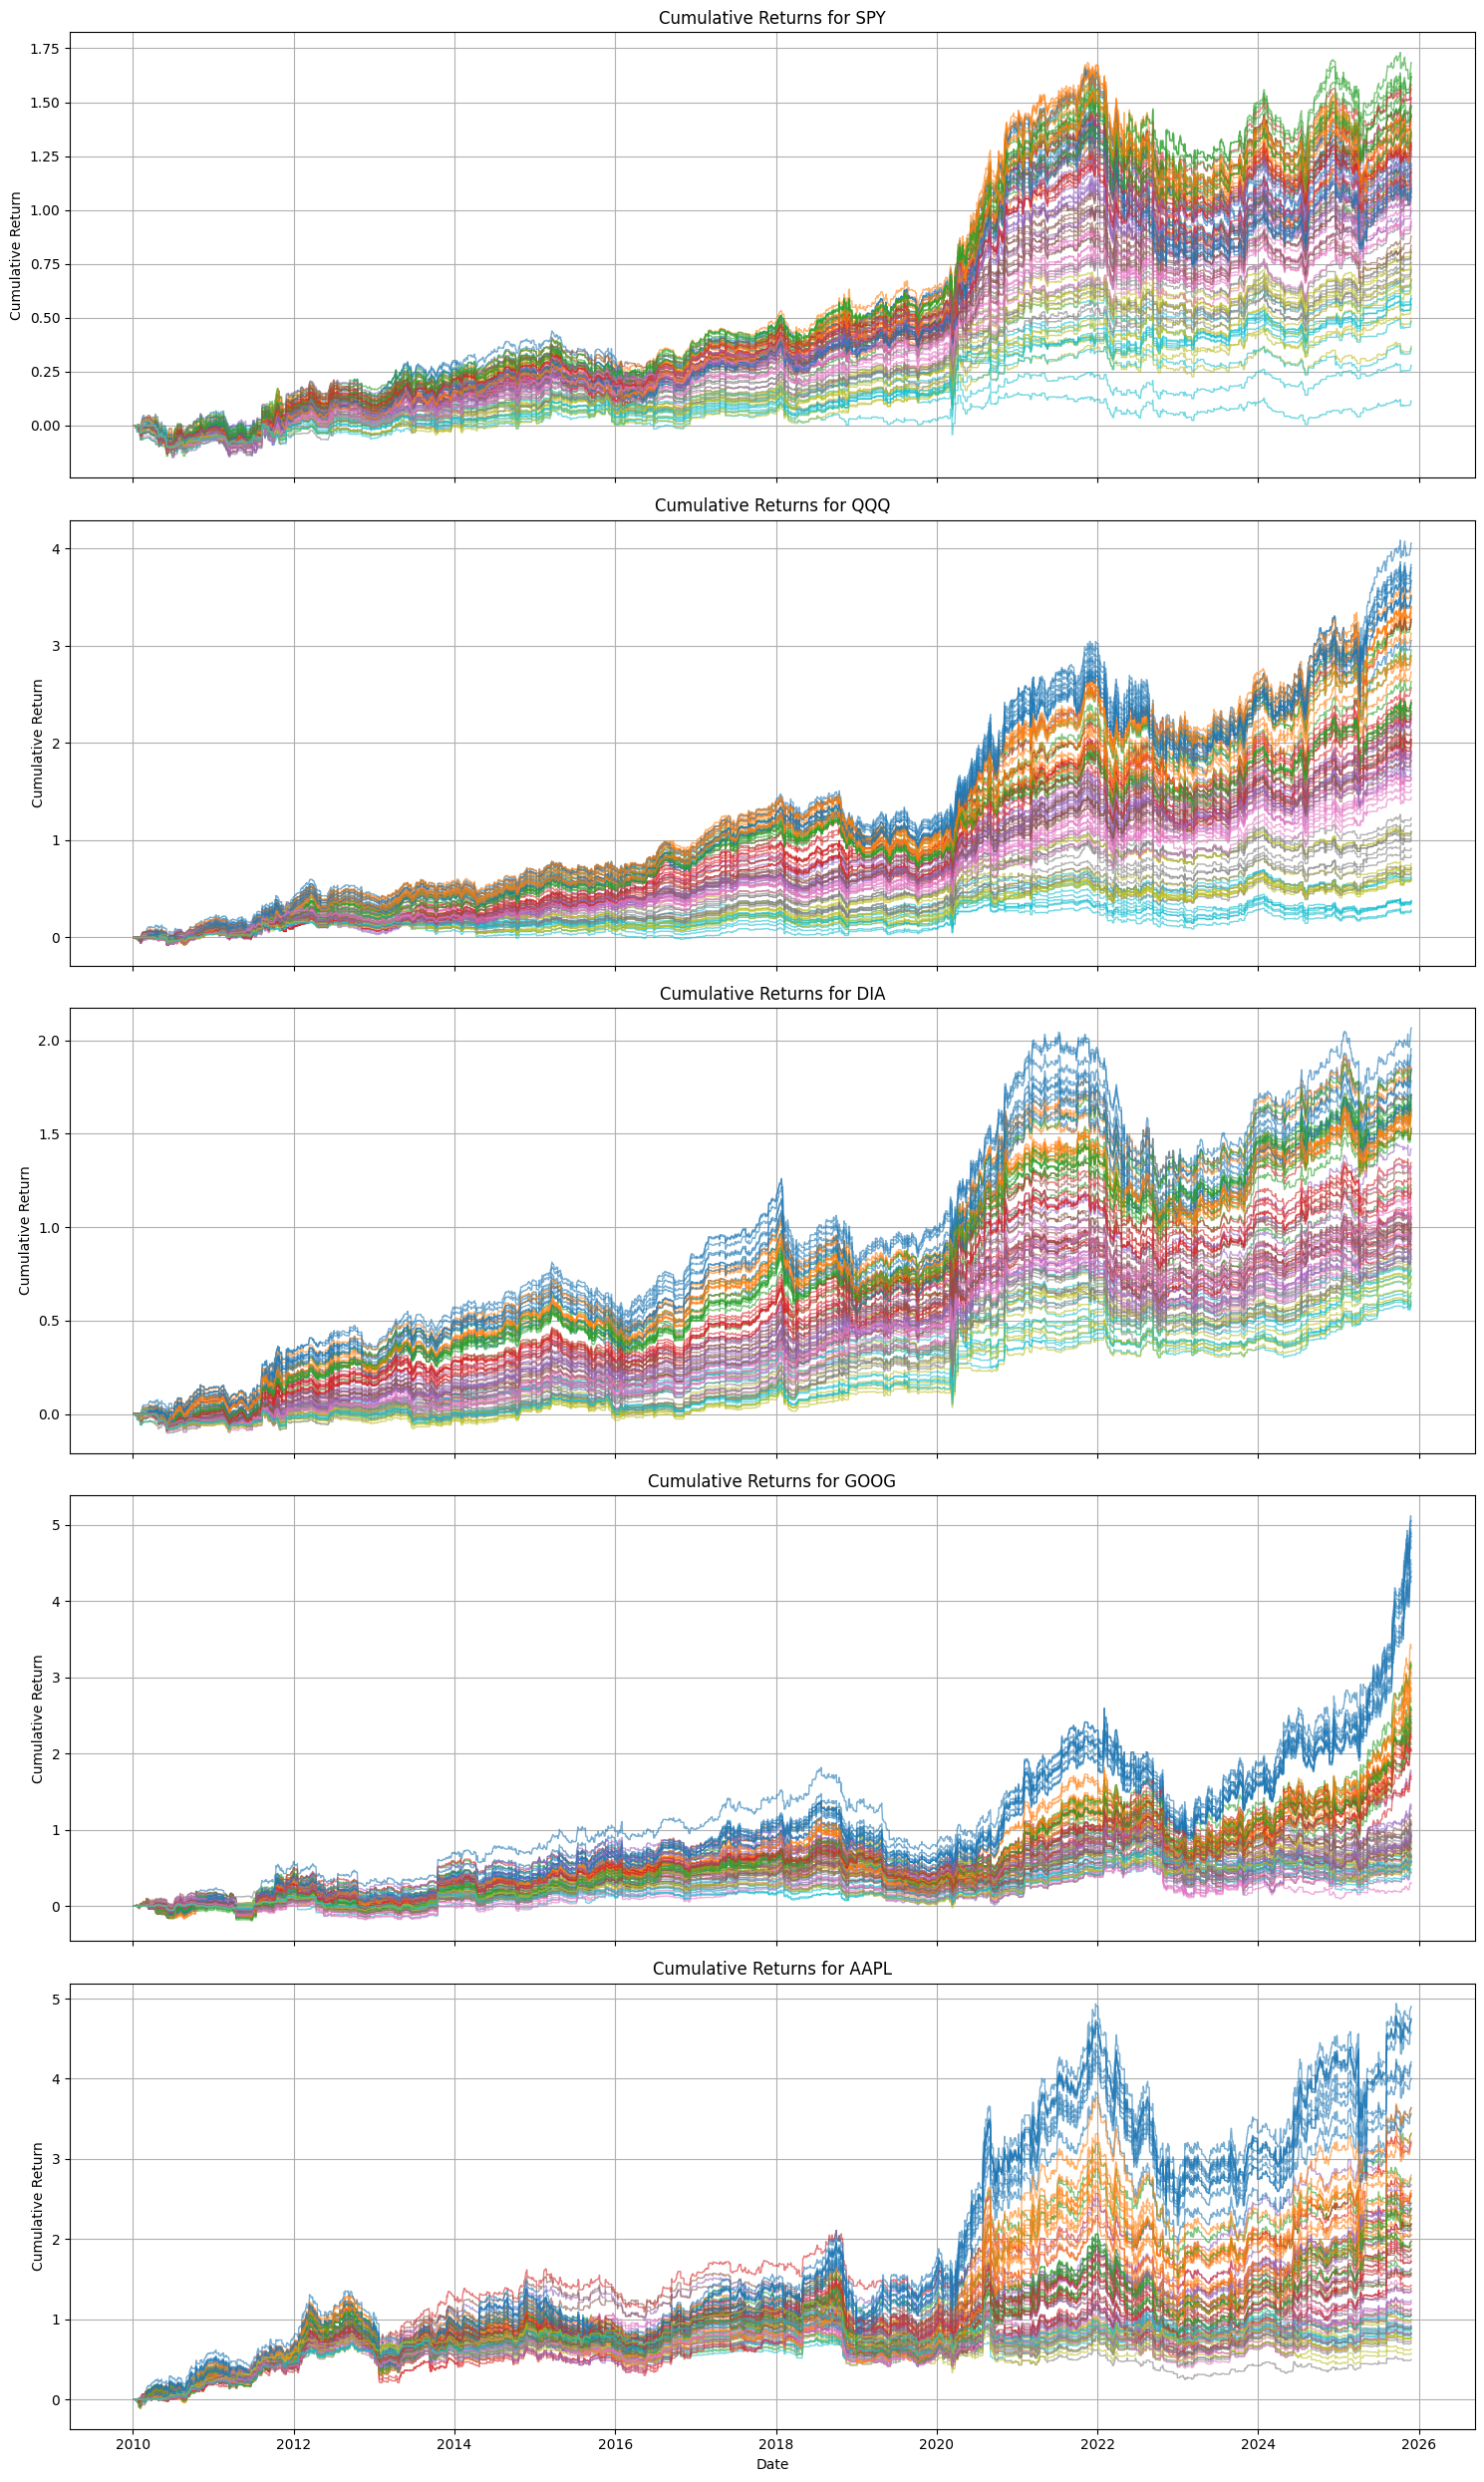

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

tickers = close_prices.columns.tolist()
lookback_windows = range(5, 51, 5)  # e.g. 5, 10, ..., 50
k_factors = np.arange(0.1, 1.1, 0.1)  # e.g. 0.1 to 1.0

fig, axes = plt.subplots(nrows=len(tickers), ncols=1, figsize=(15, 5 * len(tickers)), sharex=True)

if len(tickers) == 1:
    axes = [axes]

for ax, ticker in zip(axes, tickers):
    for window in lookback_windows:
        for k in k_factors:
            # Generate signals for parameters
            signals = volatility_breakout_strategy(close_prices[[ticker]], k=k, window=window)

            daily_returns = close_prices[ticker].pct_change().shift(-1).fillna(0)
            strategy_returns = daily_returns * signals[ticker].shift(1).fillna(False).astype(int)

            cumulative_returns = (1 + strategy_returns).cumprod() - 1

            # Plot without legend labels or label='_nolegend_'
            ax.plot(cumulative_returns.index, cumulative_returns, alpha=0.6, linewidth=1, label='_nolegend_')

    ax.set_title(f'Cumulative Returns for {ticker}')
    ax.set_ylabel('Cumulative Return')
    ax.grid(True)

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()


/tmp/ipython-input-2012760713.py:40: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


<Figure size 1200x600 with 0 Axes>

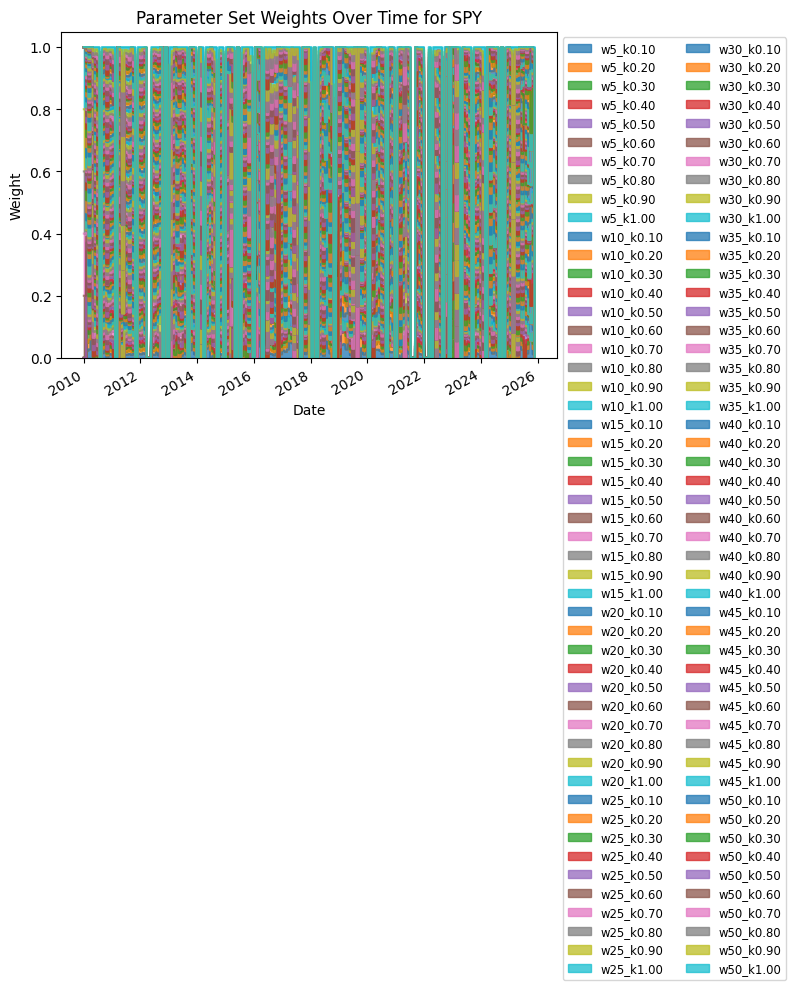

/tmp/ipython-input-2012760713.py:40: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


<Figure size 1200x600 with 0 Axes>

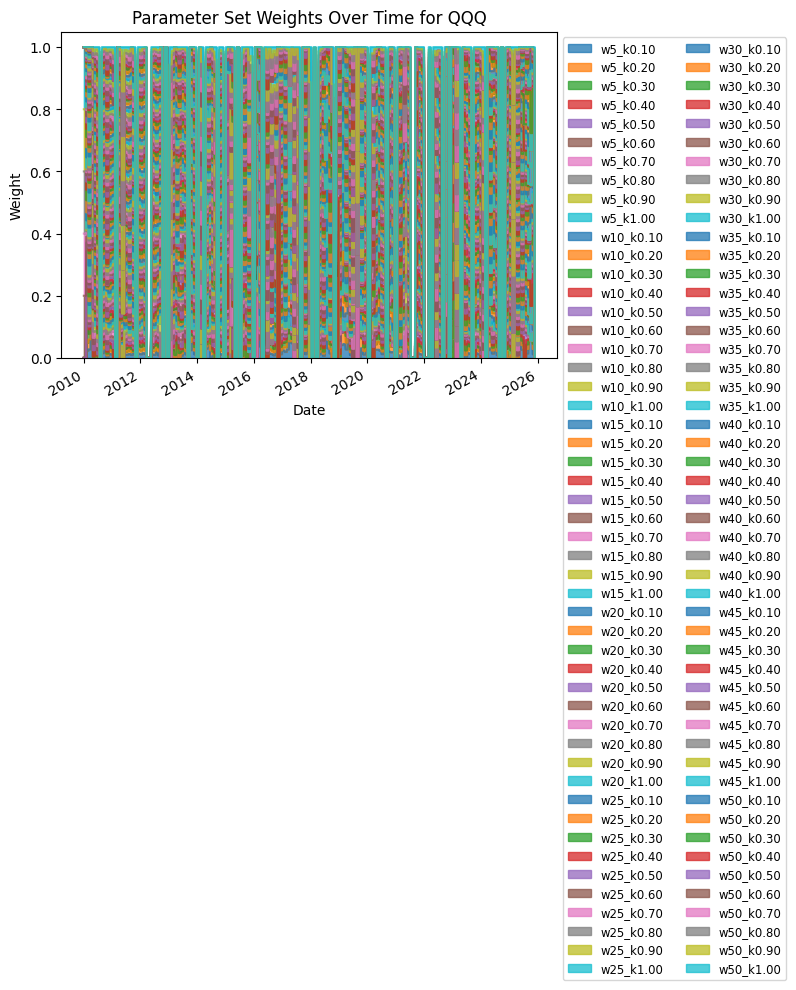

/tmp/ipython-input-2012760713.py:40: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


<Figure size 1200x600 with 0 Axes>

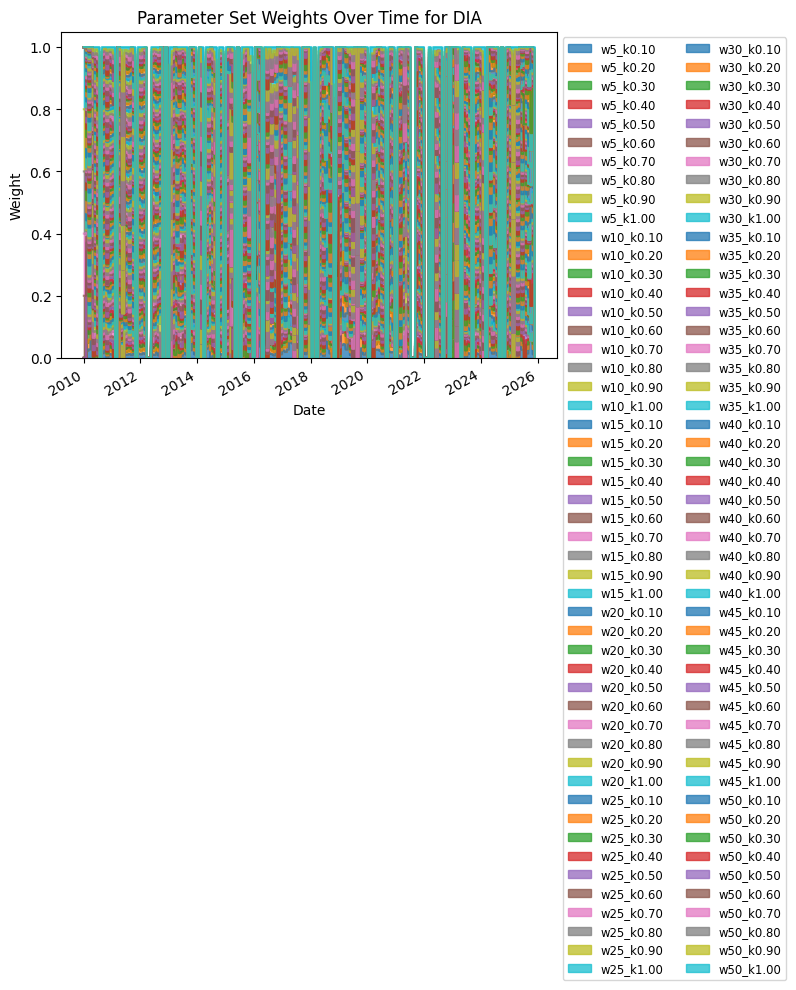

/tmp/ipython-input-2012760713.py:40: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


<Figure size 1200x600 with 0 Axes>

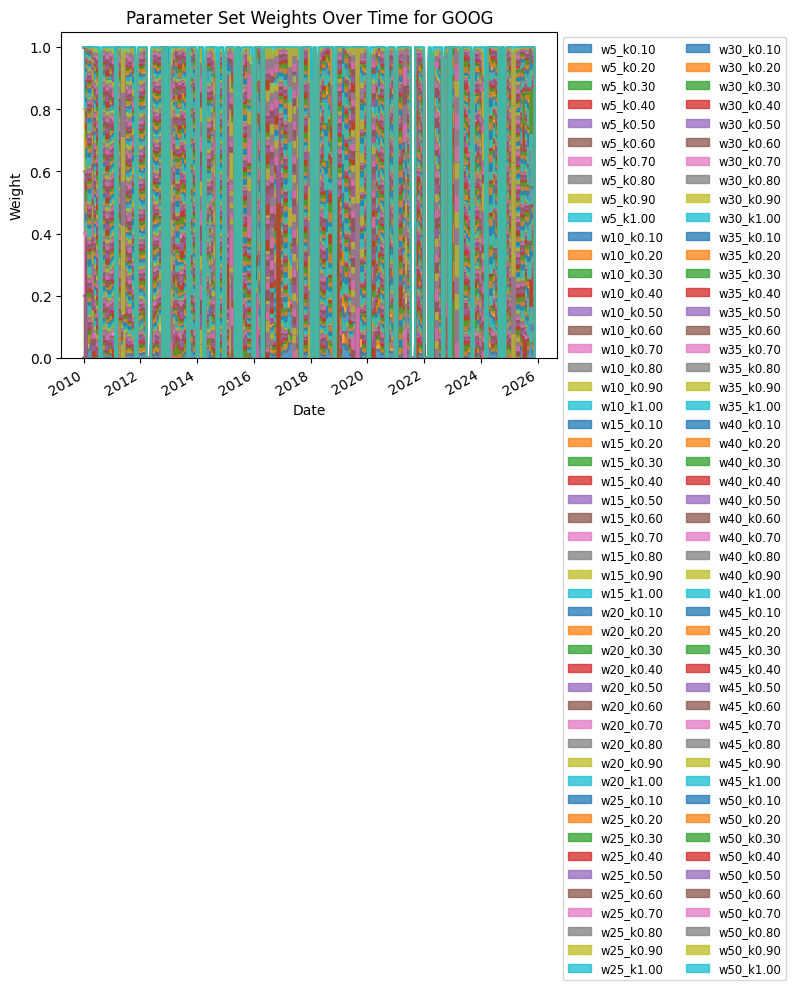

/tmp/ipython-input-2012760713.py:40: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


<Figure size 1200x600 with 0 Axes>

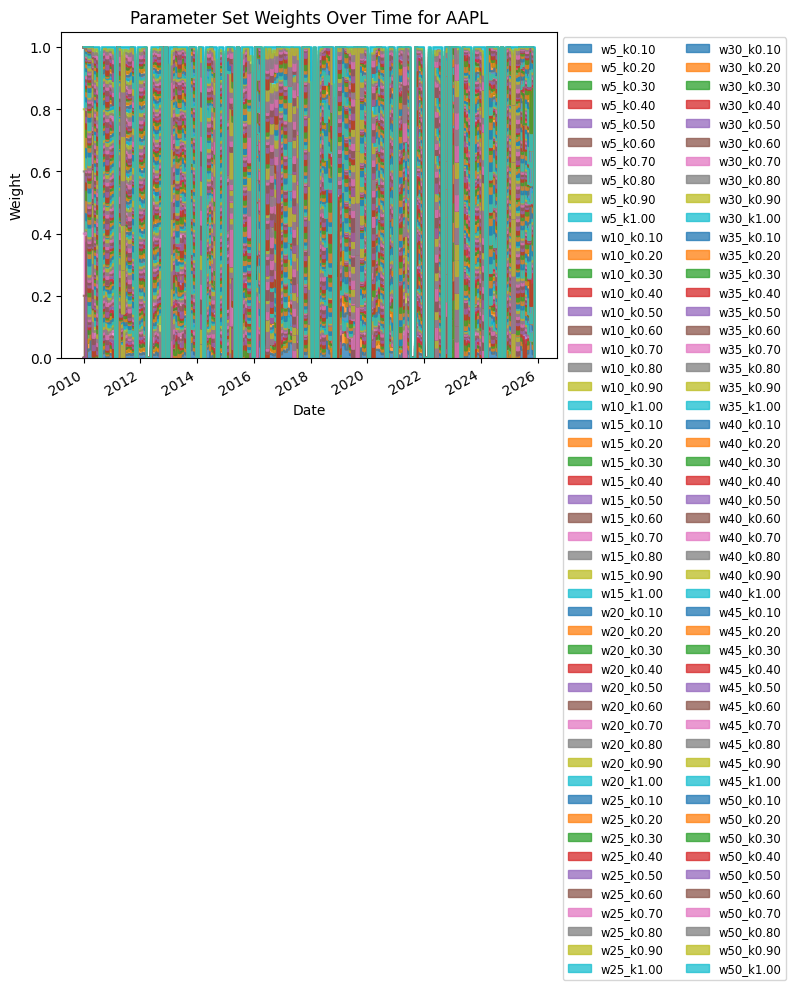

In [9]:
import matplotlib.pyplot as plt

tickers = close_prices.columns.tolist()
rebalance_period = 20

for ticker in tickers:
    # Assume all_strategy_returns calculated as before, indexed by date and columns = parameter strings

    # Collect weights at each rebalance period
    weights_over_time = pd.DataFrame(index=all_strategy_returns.index, columns=all_strategy_returns.columns)

    previous_weights = pd.Series(0, index=all_strategy_returns.columns)

    for start in range(0, len(all_strategy_returns), rebalance_period):
        end = min(start + rebalance_period, len(all_strategy_returns))
        window_returns = all_strategy_returns.iloc[start:end]

        performance = (1 + window_returns).prod() - 1
        positive_perf = performance.clip(lower=0)
        total_perf = positive_perf.sum()

        if total_perf == 0:
            weights = positive_perf * 0
        else:
            weights = positive_perf / total_perf

        weights_over_time.iloc[start:end] = weights.values  # fill weights for the entire period

        previous_weights = weights

    weights_over_time.fillna(0, inplace=True)

    # Plot stacked area of weights to show parameter set allocation over time
    plt.figure(figsize=(12, 6))
    weights_over_time.plot.area(stacked=True, alpha=0.75)
    plt.title(f'Parameter Set Weights Over Time for {ticker}')
    plt.ylabel('Weight')
    plt.xlabel('Date')
    plt.legend(loc='upper left', bbox_to_anchor=(1,1), fontsize='small', ncol=2)
    plt.tight_layout()
    plt.show()


# Task
Revise the backtesting of the volatility breakout strategy in the notebook to eliminate look-ahead bias. This involves three steps: first, modify the `volatility_breakout_strategy` function to ensure that signals for day 't' are based solely on data available at the end of day 't-1'; second, adjust the `daily_returns` calculation to represent returns from `close[t-1]` to `close[t]` without a forward shift; and third, modify the `strategy_returns` calculation to apply the signal for day 't' directly to the daily return of day 't' without a signal shift.

## Modify volatility_breakout_strategy

### Subtask:
Redefine the `volatility_breakout_strategy` function within cell `rFGHXVK4gPsr` to ensure that a signal for day 't' is generated based entirely on data available at the end of day 't-1'. This means the breakout condition for day 't' will check if `close[t-1]` broke above a threshold calculated using `close[t-2]` and `volatility[t-2]`.


**Reasoning**:
The subtask requires redefining the `volatility_breakout_strategy` function within cell `rFGHXVK4gPsr` to ensure signals are generated based on data available at `t-1`. This involves updating the function with the provided logic and replacing the content of the specified cell.



**Reasoning**:
The previous execution produced a `FutureWarning` related to the use of `fillna(method='ffill')`. To address this, I will update the code to use the recommended `ffill()` method directly, ensuring future compatibility and resolving the warning.



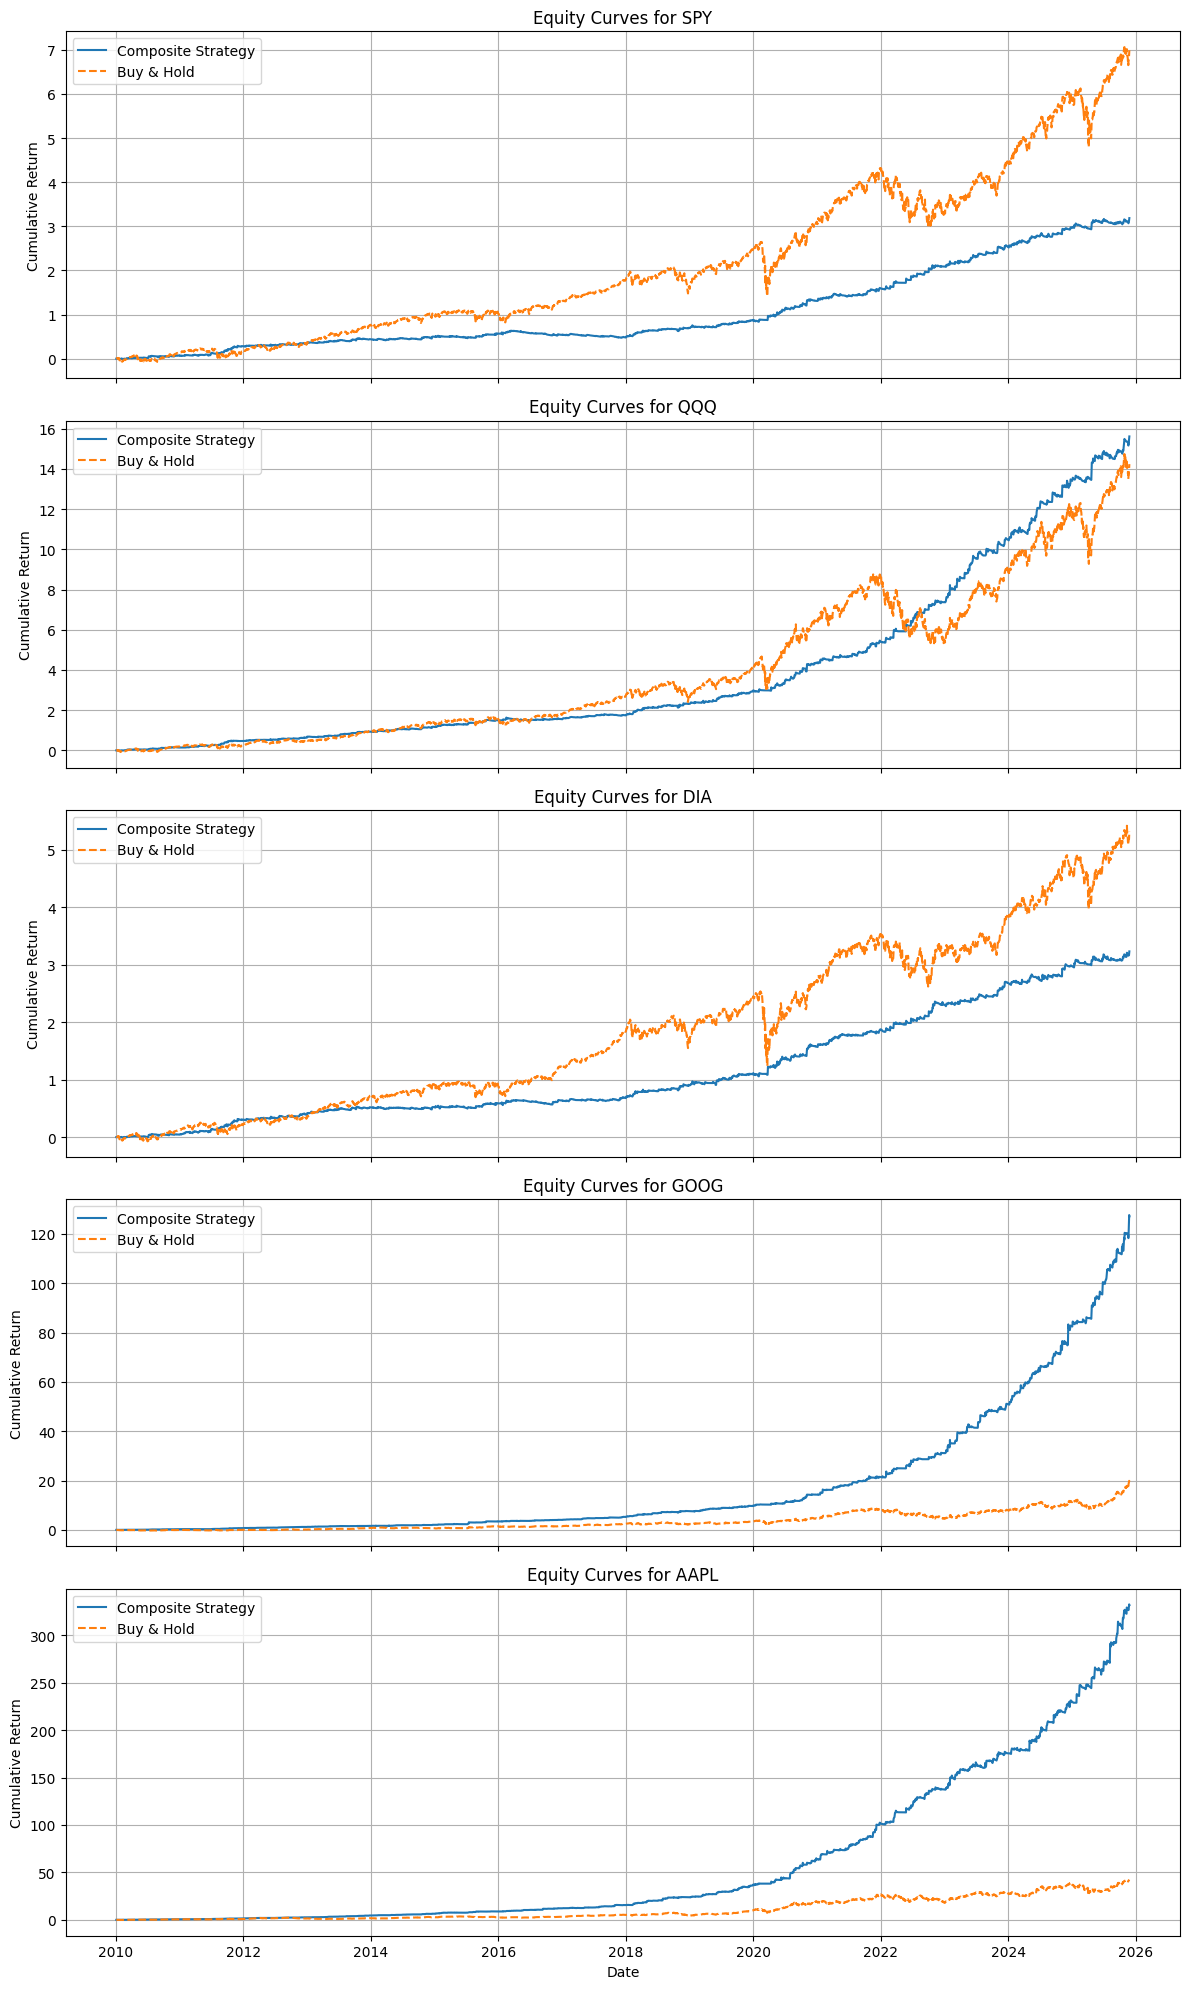

In [12]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Suppress pandas FutureWarning for downcasting issues
pd.set_option('future.no_silent_downcasting', True)

def volatility_breakout_strategy(df_close, k=0.5, window=20):
    # Calculate daily returns volatility as rolling std of pct change
    # vol[t] uses data up to t, so vol.shift(2)[t] provides vol[t-2]
    vol = df_close.pct_change().rolling(window=window).std()

    # Calculate breakout threshold for day 't' using data available at the end of day 't-2'
    # breakout_threshold[t] will be close[t-2] * (1 + k * vol[t-2])
    breakout_threshold = df_close.shift(2) * (1 + k * vol.shift(2))

    # Define buy signals for day 't': check if close[t-1] breaks above the threshold calculated at t-2
    # signals[t] will be True if df_close[t-1] > breakout_threshold[t]
    signals = df_close.shift(1) > breakout_threshold

    return signals

tickers = close_prices.columns.tolist()
lookback_windows = range(5, 51, 5)  # Lookback periods: 5, 10, ..., 50
k_factors = np.arange(0.1, 1.1, 0.1)  # ATR multipliers: 0.1 to 1.0

rebalance_period = 5  # rebalance every 20 trading days

transaction_cost_per_trade = 0.0041  # e.g., 0.1% per round trip trade

composite_equity_curves = {}

for ticker in tickers:
    all_strategy_returns = pd.DataFrame(index=close_prices.index)

    for window in lookback_windows:
        for k in k_factors:
            signals = volatility_breakout_strategy(close_prices[[ticker]], k=k, window=window)
            # Calculate daily returns (close[t] - close[t-1]) / close[t-1] without forward shift
            daily_returns = close_prices[ticker].pct_change().fillna(0)
            # Apply signal for day 't' to the daily return of day 't' without signal shift
            strategy_returns = daily_returns * signals[ticker].fillna(False).astype(int)
            col_name = f"w{window}_k{k:.2f}"
            all_strategy_returns[col_name] = strategy_returns

    composite_returns = pd.Series(index=close_prices.index)
    previous_weights = pd.Series(0, index=all_strategy_returns.columns)

    for start in range(0, len(all_strategy_returns), rebalance_period):
        end = min(start + rebalance_period, len(all_strategy_returns))
        window_returns = all_strategy_returns.iloc[start:end]

        performance = (1 + window_returns).prod() - 1
        positive_perf = performance.clip(lower=0)
        total_perf = positive_perf.sum()

        if total_perf == 0:
            weights = positive_perf * 0
        else:
            weights = positive_perf / total_perf

        # Calculate turnover as sum of absolute weight changes from previous period
        turnover = (weights - previous_weights).abs().sum()
        previous_weights = weights

        # Transaction cost penalty
        cost = turnover * transaction_cost_per_trade

        weighted_returns = (window_returns * weights).sum(axis=1)

        # Subtract transaction cost uniformly over period
        cost_per_day = cost / (end - start)
        weighted_returns -= cost_per_day

        composite_returns.iloc[start:end] = weighted_returns.values

    composite_returns.ffill(inplace=True)
    composite_returns.fillna(0, inplace=True)

    composite_equity_curves[ticker] = (1 + composite_returns).cumprod() - 1


#import matplotlib.pyplot as plt

# composite_equity_curves is a dict of strategy equity curves by ticker
tickers = list(composite_equity_curves.keys())

fig, axes = plt.subplots(nrows=len(tickers), ncols=1, figsize=(12, 4 * len(tickers)), sharex=True)

if len(tickers) == 1:
    axes = [axes]

for ax, ticker in zip(axes, tickers):
    equity_curve = composite_equity_curves[ticker]

    # Compute buy-and-hold cumulative returns for ticker
    bh_prices = close_prices[ticker]
    bh_returns = bh_prices.pct_change().fillna(0)
    bh_cum_return = (1 + bh_returns).cumprod() - 1

    # Plot composite strategy equity curve
    ax.plot(equity_curve.index, equity_curve, label='Composite Strategy')

    # Overlay buy-and-hold equity curve
    ax.plot(bh_cum_return.index, bh_cum_return, label='Buy & Hold', linestyle='--')

    ax.set_title(f'Equity Curves for {ticker}')
    ax.set_ylabel('Cumulative Return')
    ax.grid(True)
    ax.legend()

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

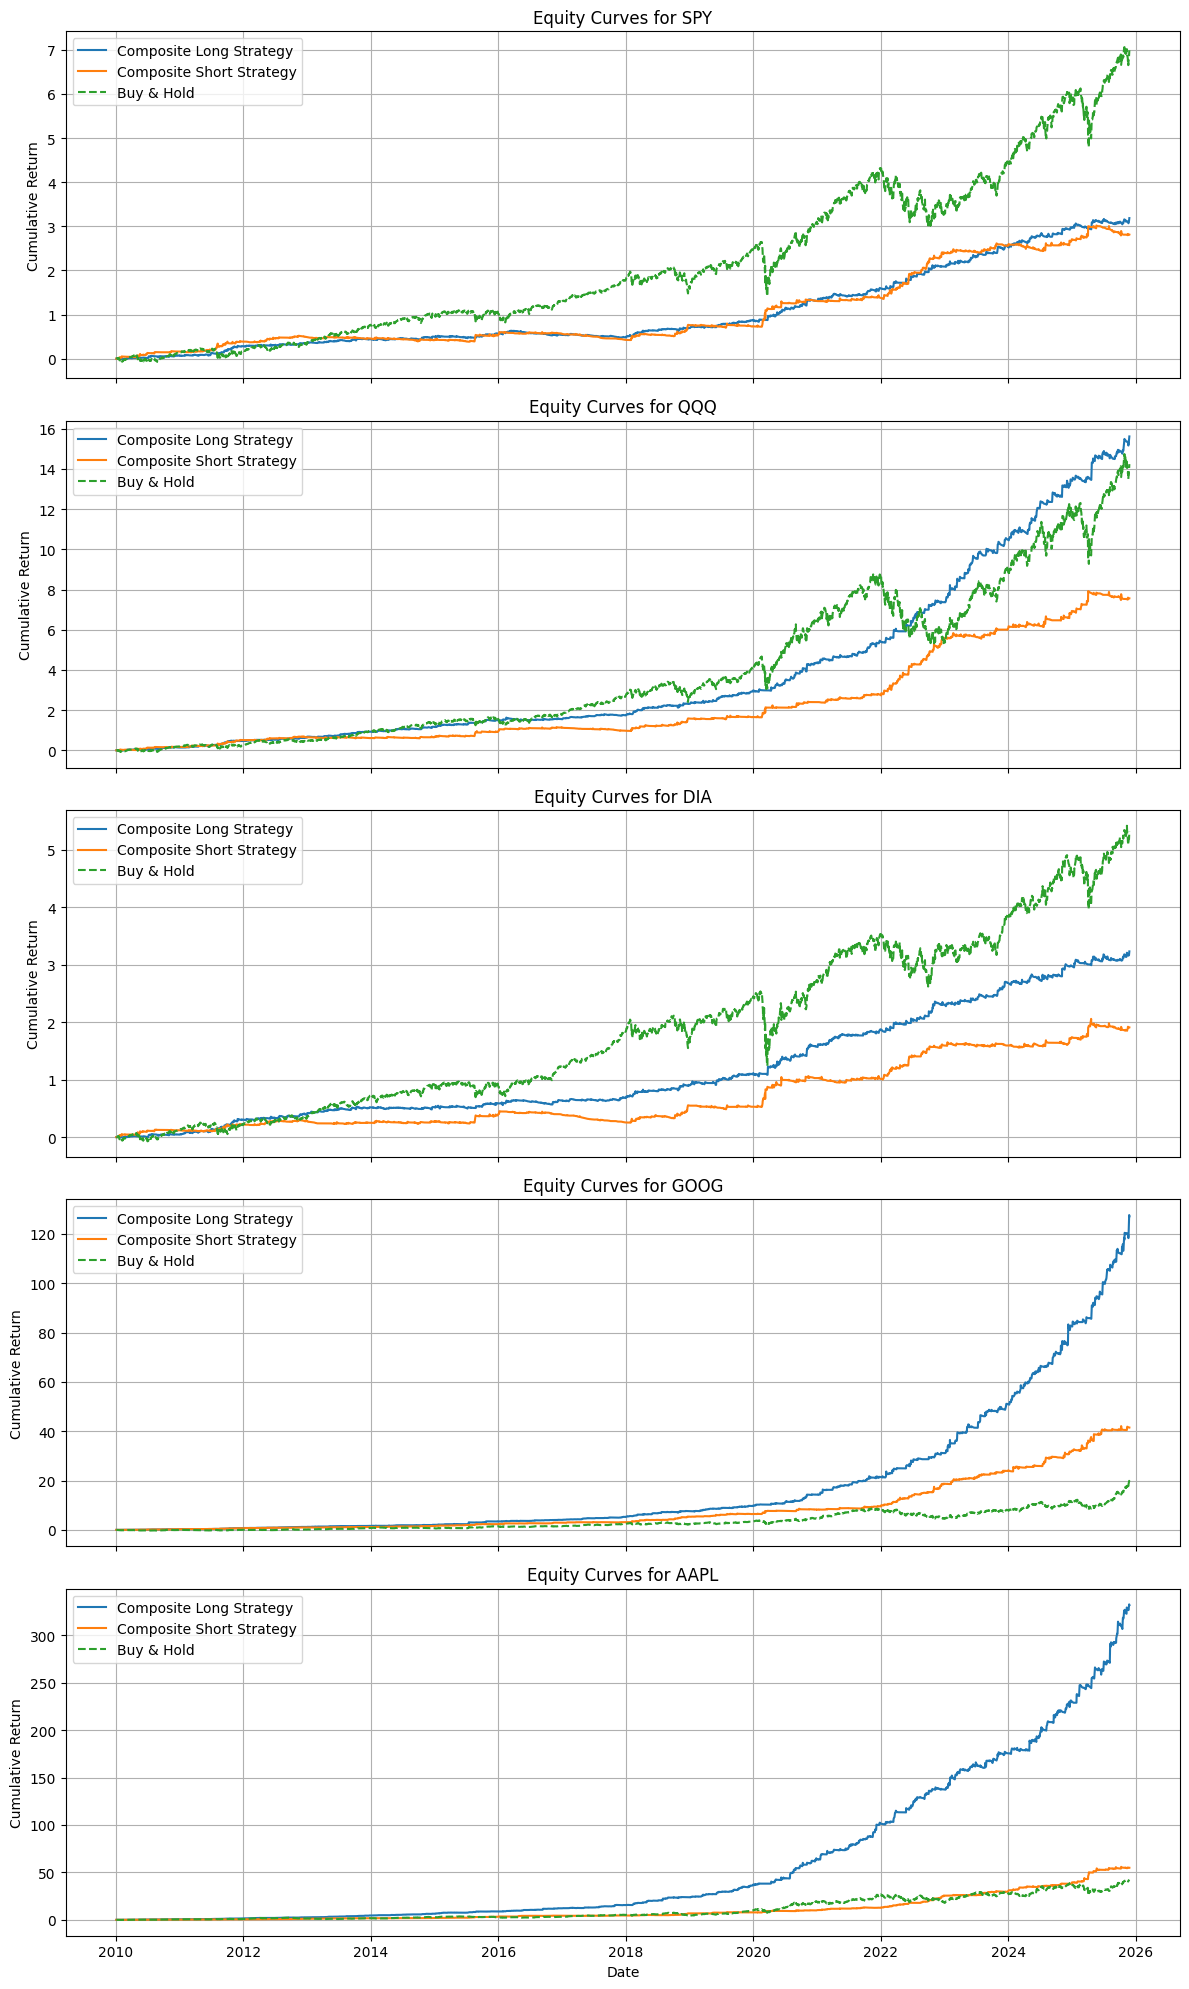

In [14]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Suppress pandas FutureWarning for downcasting issues
pd.set_option('future.no_silent_downcasting', True)

def volatility_breakout_strategy(df_close, k=0.5, window=20):
    # Calculate daily returns volatility as rolling std of pct change
    # vol[t] uses data up to t, so vol.shift(2)[t] provides vol[t-2]
    vol = df_close.pct_change().rolling(window=window).std()

    # Calculate breakout threshold for day 't' using data available at the end of day 't-2'
    # breakout_threshold[t] will be close[t-2] * (1 + k * vol[t-2])
    breakout_threshold = df_close.shift(2) * (1 + k * vol.shift(2))

    # Define buy signals for day 't': check if close[t-1] breaks above the threshold calculated at t-2
    # signals[t] will be True if df_close[t-1] > breakout_threshold[t]
    signals = df_close.shift(1) > breakout_threshold

    return signals

def volatility_breakout_short_strategy(df_close, k=0.5, window=20):
    # Calculate daily returns volatility as rolling std of pct change
    vol = df_close.pct_change().rolling(window=window).std()

    # Calculate lower breakout threshold for day 't' using data available at the end of day 't-2'
    # breakout_threshold[t] will be close[t-2] * (1 - k * vol[t-2])
    lower_breakout_threshold = df_close.shift(2) * (1 - k * vol.shift(2))

    # Define short signals for day 't': check if close[t-1] breaks below the lower threshold calculated at t-2
    # signals[t] will be True if df_close[t-1] < lower_breakout_threshold[t]
    signals = df_close.shift(1) < lower_breakout_threshold

    return signals

tickers = close_prices.columns.tolist()
lookback_windows = range(5, 51, 5)  # Lookback periods: 5, 10, ..., 50
k_factors = np.arange(0.1, 1.1, 0.1)  # ATR multipliers: 0.1 to 1.0

rebalance_period = 5  # rebalance every 20 trading days

transaction_cost_per_trade = 0.0041  # e.g., 0.1% per round trip trade

composite_equity_curves = {}
composite_short_equity_curves = {}

for ticker in tickers:
    all_strategy_returns = pd.DataFrame(index=close_prices.index)
    all_short_strategy_returns = pd.DataFrame(index=close_prices.index)

    for window in lookback_windows:
        for k in k_factors:
            # Long Strategy Returns
            signals_long = volatility_breakout_strategy(close_prices[[ticker]], k=k, window=window)
            daily_returns = close_prices[ticker].pct_change().fillna(0)
            strategy_returns_long = daily_returns * signals_long[ticker].fillna(False).astype(int)
            col_name = f"w{window}_k{k:.2f}"
            all_strategy_returns[col_name] = strategy_returns_long

            # Short Strategy Returns
            signals_short = volatility_breakout_short_strategy(close_prices[[ticker]], k=k, window=window)
            # Multiply by -1 for short selling profit/loss
            strategy_returns_short = daily_returns * signals_short[ticker].fillna(False).astype(int) * -1
            all_short_strategy_returns[col_name] = strategy_returns_short

    # Rebalancing logic for Long Strategy
    composite_returns_long = pd.Series(index=close_prices.index)
    previous_weights_long = pd.Series(0, index=all_strategy_returns.columns)

    for start in range(0, len(all_strategy_returns), rebalance_period):
        end = min(start + rebalance_period, len(all_strategy_returns))
        window_returns_long = all_strategy_returns.iloc[start:end]

        performance_long = (1 + window_returns_long).prod() - 1
        positive_perf_long = performance_long.clip(lower=0)
        total_perf_long = positive_perf_long.sum()

        if total_perf_long == 0:
            weights_long = positive_perf_long * 0
        else:
            weights_long = positive_perf_long / total_perf_long

        turnover_long = (weights_long - previous_weights_long).abs().sum()
        previous_weights_long = weights_long

        cost_long = turnover_long * transaction_cost_per_trade

        weighted_returns_long = (window_returns_long * weights_long).sum(axis=1)

        cost_per_day_long = cost_long / (end - start)
        weighted_returns_long -= cost_per_day_long

        composite_returns_long.iloc[start:end] = weighted_returns_long.values

    composite_returns_long.ffill(inplace=True)
    composite_returns_long.fillna(0, inplace=True)

    composite_equity_curves[ticker] = (1 + composite_returns_long).cumprod() - 1

    # Rebalancing logic for Short Strategy
    composite_returns_short = pd.Series(index=close_prices.index)
    previous_weights_short = pd.Series(0, index=all_short_strategy_returns.columns)

    for start in range(0, len(all_short_strategy_returns), rebalance_period):
        end = min(start + rebalance_period, len(all_short_strategy_returns))
        window_returns_short = all_short_strategy_returns.iloc[start:end]

        performance_short = (1 + window_returns_short).prod() - 1
        # Corrected calculation for positive performance in short strategies
        positive_perf_short = performance_short.clip(lower=0)
        total_perf_short = positive_perf_short.sum()

        if total_perf_short == 0:
            weights_short = positive_perf_short * 0
        else:
            weights_short = positive_perf_short / total_perf_short

        turnover_short = (weights_short - previous_weights_short).abs().sum()
        previous_weights_short = weights_short

        cost_short = turnover_short * transaction_cost_per_trade

        weighted_returns_short = (window_returns_short * weights_short).sum(axis=1)

        cost_per_day_short = cost_short / (end - start)
        weighted_returns_short -= cost_per_day_short

        composite_returns_short.iloc[start:end] = weighted_returns_short.values

    composite_returns_short.ffill(inplace=True)
    composite_returns_short.fillna(0, inplace=True)

    composite_short_equity_curves[ticker] = (1 + composite_returns_short).cumprod() - 1


# composite_equity_curves is a dict of strategy equity curves by ticker
tickers = list(composite_equity_curves.keys())

fig, axes = plt.subplots(nrows=len(tickers), ncols=1, figsize=(12, 4 * len(tickers)), sharex=True)

if len(tickers) == 1:
    axes = [axes]

for ax, ticker in zip(axes, tickers):
    equity_curve_long = composite_equity_curves[ticker]
    equity_curve_short = composite_short_equity_curves[ticker]

    # Compute buy-and-hold cumulative returns for ticker
    bh_prices = close_prices[ticker]
    bh_returns = bh_prices.pct_change().fillna(0)
    bh_cum_return = (1 + bh_returns).cumprod() - 1

    # Plot composite strategy equity curve
    ax.plot(equity_curve_long.index, equity_curve_long, label='Composite Long Strategy')
    ax.plot(equity_curve_short.index, equity_curve_short, label='Composite Short Strategy')

    # Overlay buy-and-hold equity curve
    ax.plot(bh_cum_return.index, bh_cum_return, label='Buy & Hold', linestyle='--')

    ax.set_title(f'Equity Curves for {ticker}')
    ax.set_ylabel('Cumulative Return')
    ax.grid(True)
    ax.legend()

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

## Visualizing Signal Generation for Long and Short Strategies

## Table of Contents

- [Data Acquisition](#Data-Acquisition)
- [Strategy Definitions](#Strategy-Definitions)
- [Backtesting and Rebalancing](#Backtesting-and-Rebalancing)
- [Heatmap Generation](#Heatmap-Generation)
- [Episodic Returns Analysis](#Episodic-Returns-Analysis)
- [Signal Visualization](#Signal-Visualization)
- [Conclusions](#Conclusions)

<a id='Data-Acquisition'></a>
## Data Acquisition

This section handles the initial data acquisition for historical stock prices using `yfinance` and prepares the `close_prices` DataFrame.

In [17]:
# Install yfinance once per session
!pip install yfinance --quiet

# Import libraries
import yfinance as yf
import pandas as pd

# Define the ticker symbols and date range
ticker_symbols = ['SPY', 'QQQ', 'DIA', 'GOOG', 'AAPL']  # SPY is SPDR S&P 500 ETF Trust, QQQ is Invesco QQQ Trust, DIA is SPDR Dow Jones Industrial Average ETF Trust, GOOG is Alphabet Inc., AAPL is Apple Inc.
start_date = '2010-01-01'
end_date = '2026-11-25'

# Download historical data for all tickers with adjusted close prices
data = yf.download(ticker_symbols, start=start_date, end=end_date, progress=True, auto_adjust=True, group_by='ticker', threads=True)

# Extract Close price for each ticker into a single DataFrame
close_prices = pd.DataFrame({ticker: data[ticker]['Close'] for ticker in ticker_symbols})

# Display the first few rows of Close price data
(close_prices.head())

[*********************100%***********************]  5 of 5 completed


,SPY,QQQ,DIA,GOOG,AAPL
Date,,,,,
2010-01-04,85.279182,40.393562,75.132156,15.504140,6.418384
2010-01-05,85.504959,40.393562,75.011284,15.435866,6.429480
2010-01-06,85.565155,40.149914,75.061043,15.046746,6.327211
2010-01-07,85.926353,40.176033,75.331299,14.696465,6.315515
2010-01-08,86.212288,40.506699,75.452110,14.892385,6.357502


<a id='Strategy-Definitions'></a>
## Strategy Definitions

This section consolidates the final, corrected definitions for both the `volatility_breakout_strategy` (for long signals) and `volatility_breakout_short_strategy` (for short signals). These functions are designed to generate signals based on data available at `t-1` and `t-2` to eliminate look-ahead bias.

In [18]:
import numpy as np
import pandas as pd

# Suppress pandas FutureWarning for downcasting issues
pd.set_option('future.no_silent_downcasting', True)

def volatility_breakout_strategy(df_close, k=0.5, window=20):
    """
    Volatility Breakout Strategy (Long):
    Generates a buy signal for day 't' if close[t-1] breaks above a threshold
    calculated using close[t-2] and volatility[t-2].

    Args:
        df_close: DataFrame with Close prices indexed by date, columns = tickers
        k: multiplier for volatility range
        window: window size for volatility calc

    Returns:
        signals: DataFrame of boolean buy signals for each ticker and date
    """
    # Calculate daily returns volatility as rolling std of pct change
    # vol[t] uses data up to t, so vol.shift(2)[t] provides vol[t-2]
    vol = df_close.pct_change().rolling(window=window).std()

    # Calculate breakout threshold for day 't' using data available at the end of day 't-2'
    # breakout_threshold[t] will be close[t-2] * (1 + k * vol[t-2])
    breakout_threshold = df_close.shift(2) * (1 + k * vol.shift(2))

    # Define buy signals for day 't': check if close[t-1] breaks above the threshold calculated at t-2
    # signals[t] will be True if df_close[t-1] > breakout_threshold[t]
    signals = df_close.shift(1) > breakout_threshold

    return signals

def volatility_breakout_short_strategy(df_close, k=0.5, window=20):
    """
    Volatility Breakout Strategy (Short):
    Generates a short signal for day 't' if close[t-1] breaks below a lower threshold
    calculated using close[t-2] and volatility[t-2].

    Args:
        df_close: DataFrame with Close prices indexed by date, columns = tickers
        k: multiplier for volatility range
        window: window size for volatility calc

    Returns:
        signals: DataFrame of boolean short signals for each ticker and date
    """
    # Calculate daily returns volatility as rolling std of pct change
    vol = df_close.pct_change().rolling(window=window).std()

    # Calculate lower breakout threshold for day 't' using data available at the end of day 't-2'
    # breakout_threshold[t] will be close[t-2] * (1 - k * vol[t-2])
    lower_breakout_threshold = df_close.shift(2) * (1 - k * vol.shift(2))

    # Define short signals for day 't': check if close[t-1] breaks below the lower threshold calculated at t-2
    # signals[t] will be True if df_close[t-1] < lower_breakout_threshold[t]
    signals = df_close.shift(1) < lower_breakout_threshold

    return signals

<a id='Backtesting-and-Rebalancing'></a>
## Backtesting and Rebalancing

This section contains the comprehensive backtesting logic for both composite long and short volatility breakout strategies. It includes the calculation of strategy returns, dynamic rebalancing based on past performance, and the application of transaction costs. This code populates `composite_equity_curves` and `composite_short_equity_curves` which are used in subsequent plotting and analysis.

In [19]:
import numpy as np
import pandas as pd

# Suppress pandas FutureWarning for downcasting issues
pd.set_option('future.no_silent_downcasting', True)

tickers = close_prices.columns.tolist()
lookback_windows = range(5, 51, 5)  # Lookback periods: 5, 10, ..., 50
k_factors = np.arange(0.1, 1.1, 0.1)  # ATR multipliers: 0.1 to 1.0

rebalance_period = 5  # Rebalance every 5 trading days

transaction_cost_per_trade = 0.0041  # e.g., 0.41% per round trip trade

composite_equity_curves = {}
composite_short_equity_curves = {}

for ticker in tickers:
    all_strategy_returns = pd.DataFrame(index=close_prices.index)
    all_short_strategy_returns = pd.DataFrame(index=close_prices.index)

    for window in lookback_windows:
        for k in k_factors:
            # Long Strategy Returns
            signals_long = volatility_breakout_strategy(close_prices[[ticker]], k=k, window=window)
            daily_returns = close_prices[ticker].pct_change().fillna(0)
            strategy_returns_long = daily_returns * signals_long[ticker].fillna(False).astype(int)
            col_name = f"w{window}_k{k:.2f}"
            all_strategy_returns[col_name] = strategy_returns_long

            # Short Strategy Returns
            signals_short = volatility_breakout_short_strategy(close_prices[[ticker]], k=k, window=window)
            # Multiply by -1 for short selling profit/loss
            strategy_returns_short = daily_returns * signals_short[ticker].fillna(False).astype(int) * -1
            all_short_strategy_returns[col_name] = strategy_returns_short

    # Rebalancing logic for Long Strategy
    composite_returns_long = pd.Series(index=close_prices.index)
    previous_weights_long = pd.Series(0, index=all_strategy_returns.columns)

    for start in range(0, len(all_strategy_returns), rebalance_period):
        end = min(start + rebalance_period, len(all_strategy_returns))
        window_returns_long = all_strategy_returns.iloc[start:end]

        performance_long = (1 + window_returns_long).prod() - 1
        positive_perf_long = performance_long.clip(lower=0)
        total_perf_long = positive_perf_long.sum()

        if total_perf_long == 0:
            weights_long = positive_perf_long * 0
        else:
            weights_long = positive_perf_long / total_perf_long

        turnover_long = (weights_long - previous_weights_long).abs().sum()
        previous_weights_long = weights_long

        cost_long = turnover_long * transaction_cost_per_trade

        weighted_returns_long = (window_returns_long * weights_long).sum(axis=1)

        cost_per_day_long = cost_long / (end - start)
        weighted_returns_long -= cost_per_day_long

        composite_returns_long.iloc[start:end] = weighted_returns_long.values

    composite_returns_long.ffill(inplace=True)
    composite_returns_long.fillna(0, inplace=True)

    composite_equity_curves[ticker] = (1 + composite_returns_long).cumprod() - 1

    # Rebalancing logic for Short Strategy
    composite_returns_short = pd.Series(index=close_prices.index)
    previous_weights_short = pd.Series(0, index=all_short_strategy_returns.columns)

    for start in range(0, len(all_short_strategy_returns), rebalance_period):
        end = min(start + rebalance_period, len(all_short_strategy_returns))
        window_returns_short = all_short_strategy_returns.iloc[start:end]

        performance_short = (1 + window_returns_short).prod() - 1
        # Corrected calculation for positive performance in short strategies: only positive returns are considered 'positive_perf'
        positive_perf_short = performance_short.clip(lower=0)
        total_perf_short = positive_perf_short.sum()

        if total_perf_short == 0:
            weights_short = positive_perf_short * 0
        else:
            weights_short = positive_perf_short / total_perf_short

        turnover_short = (weights_short - previous_weights_short).abs().sum()
        previous_weights_short = weights_short

        cost_short = turnover_short * transaction_cost_per_trade

        weighted_returns_short = (window_returns_short * weights_short).sum(axis=1)

        cost_per_day_short = cost_short / (end - start)
        weighted_returns_short -= cost_per_day_short

        composite_returns_short.iloc[start:end] = weighted_returns_short.values

    composite_returns_short.ffill(inplace=True)
    composite_returns_short.fillna(0, inplace=True)

    composite_short_equity_curves[ticker] = (1 + composite_returns_short).cumprod() - 1

<a id='Heatmap-Generation'></a>
## Heatmap Generation

This section generates heatmaps to visualize the cumulative returns of the short volatility breakout strategy across various lookback windows and k-factor multipliers. These heatmaps help identify optimal parameter combinations for generating profitable short signals.

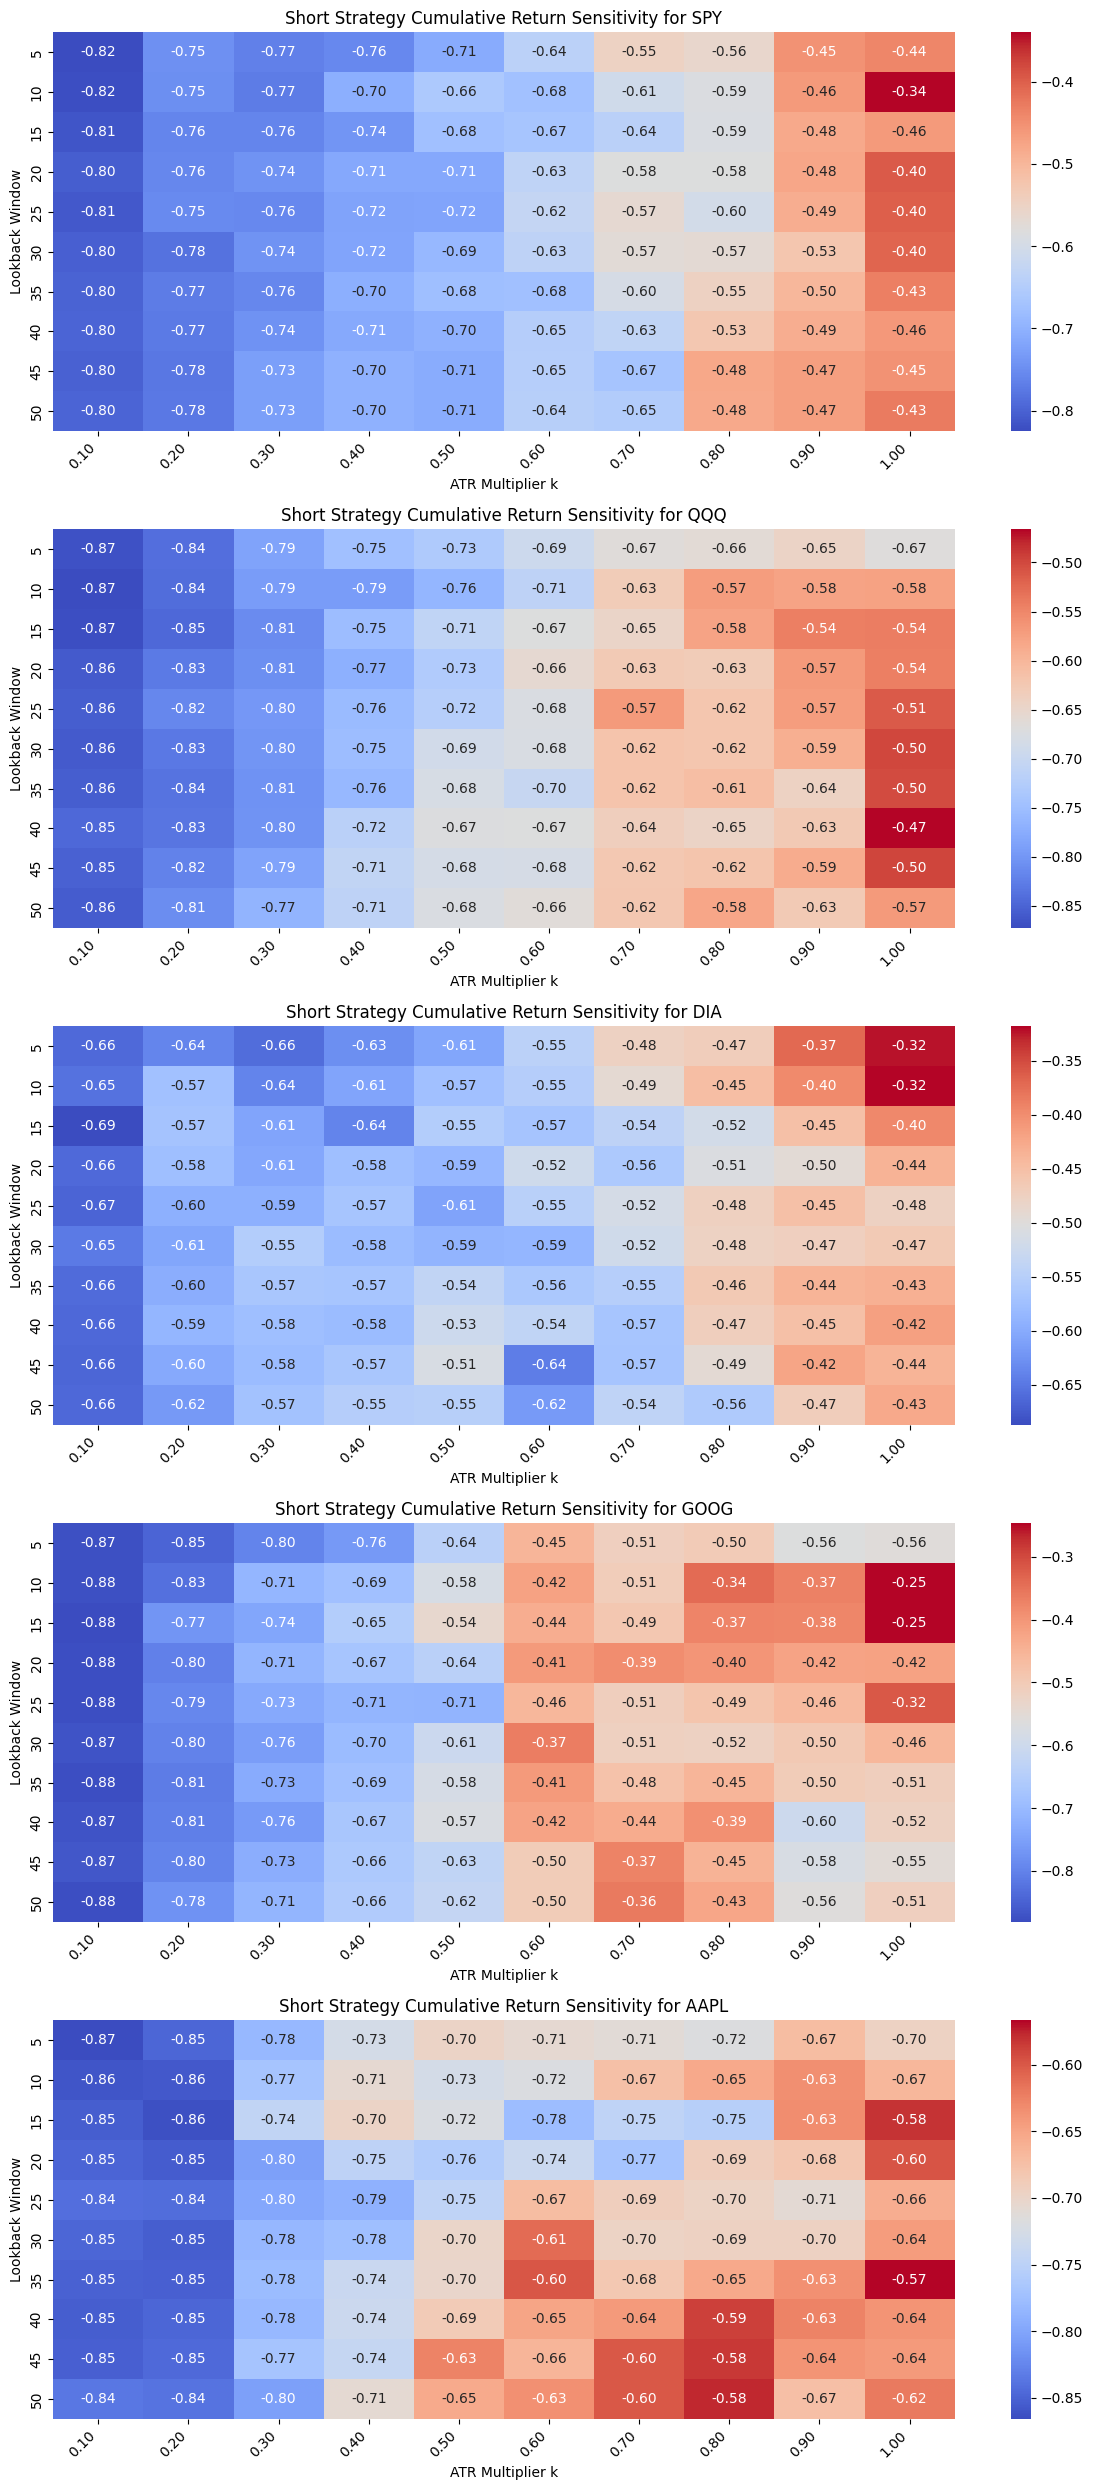

In [20]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('future.no_silent_downcasting', True)

tickers = close_prices.columns.tolist()
lookback_windows = range(5, 51, 5)
k_factors = np.arange(0.1, 1.1, 0.1)

fig, axes = plt.subplots(nrows=len(tickers), ncols=1, figsize=(12, 5 * len(tickers)))

if len(tickers) == 1:
    axes = [axes]

for ax, ticker in zip(axes, tickers):
    pnl_matrix_short = pd.DataFrame(index=lookback_windows, columns=k_factors)

    for window in lookback_windows:
        for k in k_factors:
            signals_short = volatility_breakout_short_strategy(close_prices[[ticker]], k=k, window=window)

            daily_returns = close_prices[ticker].pct_change().fillna(0)
            # Apply short signal, remember to multiply by -1 for short returns
            strategy_returns_short = daily_returns * signals_short[ticker].fillna(False).astype(int) * -1

            cumulative_return_short = (1 + strategy_returns_short).prod() - 1
            pnl_matrix_short.at[window, k] = cumulative_return_short

    pnl_matrix_short = pnl_matrix_short.astype(float)

    sns.heatmap(pnl_matrix_short, ax=ax, cmap='coolwarm', annot=True, fmt=".2f")

    ax.set_title(f'Short Strategy Cumulative Return Sensitivity for {ticker}')
    ax.set_xlabel('ATR Multiplier k')
    ax.set_ylabel('Lookback Window')

    labels = [f"{x:.2f}" for x in pnl_matrix_short.columns]
    ax.set_xticklabels(labels, rotation=45, ha='right')

plt.tight_layout()
plt.show()

<a id='Episodic-Returns-Analysis'></a>
## Episodic Returns Analysis

This section analyzes and visualizes the short strategy's episodic returns specifically during market downtrends (months where the underlying ticker experienced negative returns). This helps to assess the short strategy's effectiveness as a hedge or alpha generator during bearish market conditions.

<a id='Signal-Visualization'></a>
## Signal Visualization

This section provides an annotated plot demonstrating the precise sequencing of bar closes and volatility used to generate entry signals for both long and short strategies. This visual aid clarifies how `close[t-1]`, `close[t-2]`, and `volatility[t-2]` are used to determine `signals[t]` without look-ahead bias.

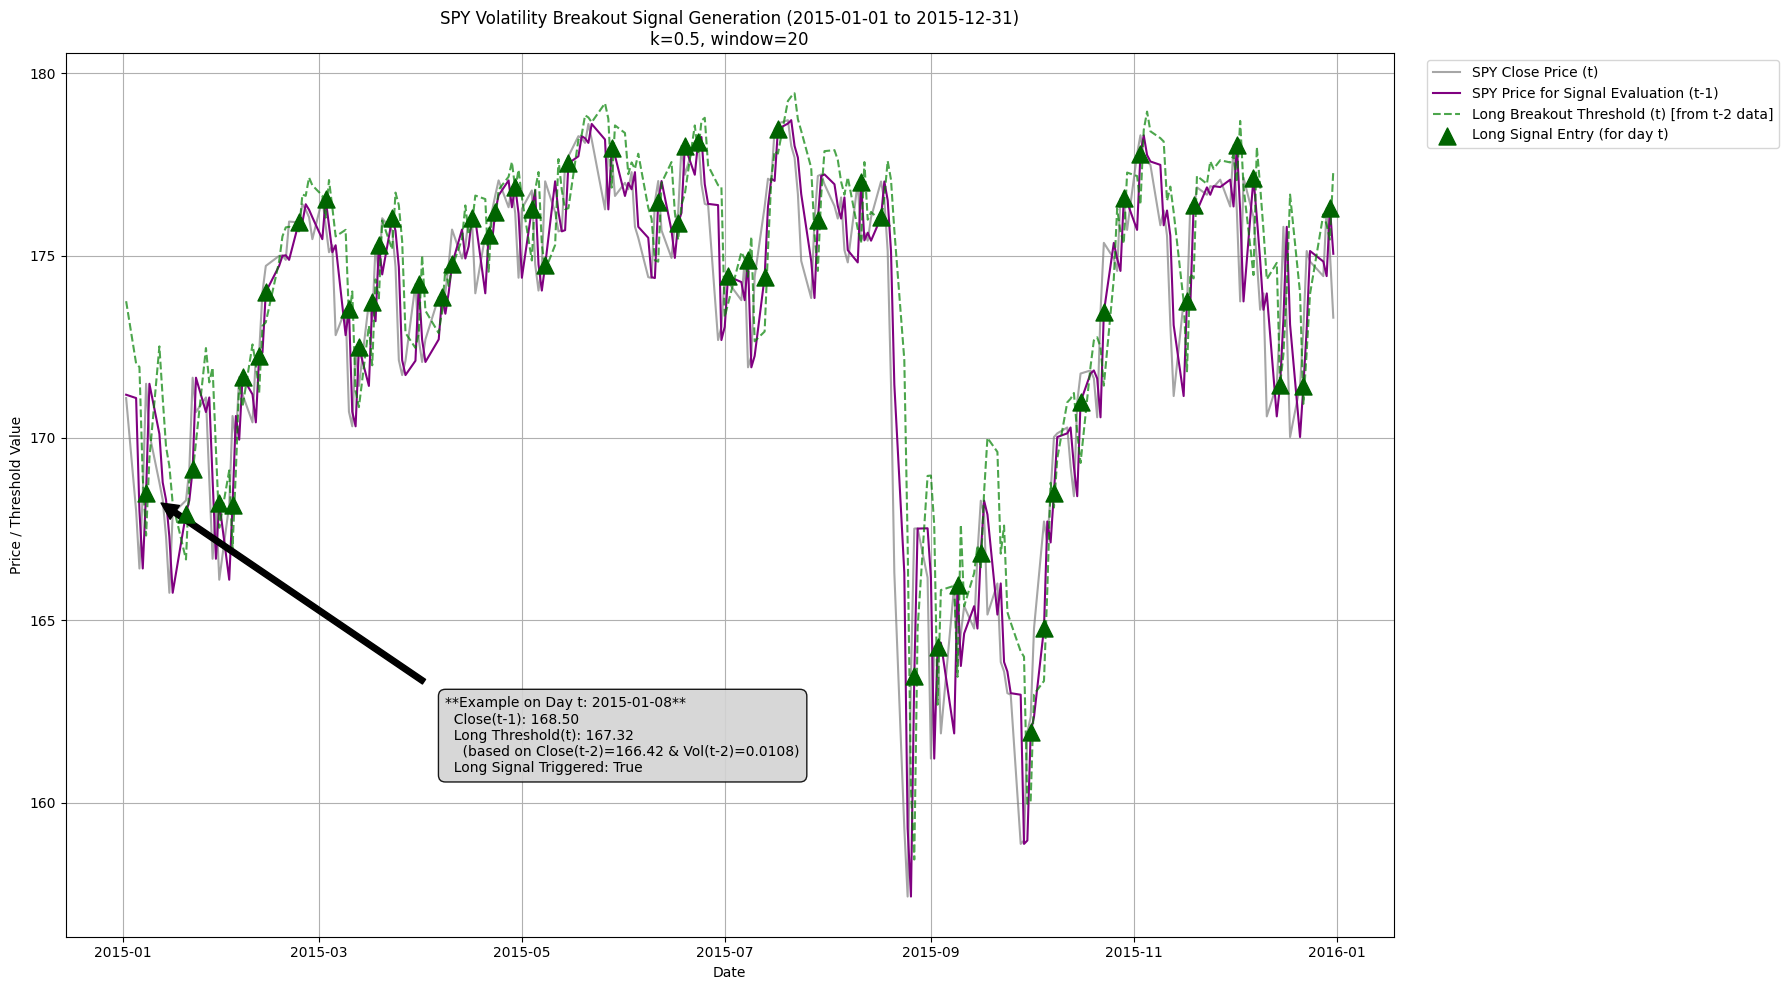

In [22]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Configuration for the plot ---

ticker_to_plot = 'SPY'
k_val = 0.5
window_val = 20
start_plot_date = '2015-01-01'
end_plot_date = '2015-12-31' # Shorter period for better visibility in the plot
show_short_signals = False # Flag to control visibility of short signals and annotation

# --- Calculate all necessary data on the full DataFrame ---
df_single_ticker = close_prices[[ticker_to_plot]]

# Calculate volatility (vol[t] uses data up to t)
# vol.shift(2)[t] provides volatility up to t-2
vol_full = df_single_ticker.pct_change().rolling(window=window_val).std()

# Calculate thresholds for day 't', using data available at t-2
breakout_threshold_long_full = df_single_ticker.shift(2) * (1 + k_val * vol_full.shift(2))
breakout_threshold_short_full = df_single_ticker.shift(2) * (1 - k_val * vol_full.shift(2))

# Generate signals for day 't', checking close[t-1] against thresholds[t]
signals_long_full = (df_single_ticker.shift(1) > breakout_threshold_long_full)
signals_short_full = (df_single_ticker.shift(1) < breakout_threshold_short_full)

# --- Prepare data for plotting within the selected date range ---
# Select the data relevant to the plotting range from the full series
plot_df = pd.DataFrame(index=df_single_ticker.loc[start_plot_date:end_plot_date].index)

plot_df['close_t'] = df_single_ticker.loc[start_plot_date:end_plot_date, ticker_to_plot]
plot_df['close_t_minus_1'] = df_single_ticker.shift(1).loc[start_plot_date:end_plot_date, ticker_to_plot]
plot_df['long_threshold_t'] = breakout_threshold_long_full.loc[start_plot_date:end_plot_date, ticker_to_plot]
if show_short_signals: # Conditionally add short threshold
    plot_df['short_threshold_t'] = breakout_threshold_short_full.loc[start_plot_date:end_plot_date, ticker_to_plot]
plot_df['signal_long'] = signals_long_full.loc[start_plot_date:end_plot_date, ticker_to_plot]
if show_short_signals: # Conditionally add short signals
    plot_df['signal_short'] = signals_short_full.loc[start_plot_date:end_plot_date, ticker_to_plot]

# Drop NaNs that result from shifting and rolling calculations at the beginning of the plot range
plot_df.dropna(inplace=True)

# --- Identify true entry signals (first day of a 'True' signal sequence) ---
# For long signals
long_entry_signals = (plot_df['signal_long'] == True) & (plot_df['signal_long'].shift(1) == False)
long_entry_dates = plot_df[long_entry_signals].index

# For short signals (only calculate if show_short_signals is True)
short_entry_dates = pd.Index([]) # Initialize as empty
if show_short_signals:
    short_entry_signals = (plot_df['signal_short'] == True) & (plot_df['signal_short'].shift(1) == False)
    short_entry_dates = plot_df[short_entry_signals].index


# --- Plotting ---
plt.figure(figsize=(18, 10))

# Plot the actual Close price (t) for context
plt.plot(plot_df.index, plot_df['close_t'], label=f'{ticker_to_plot} Close Price (t)', color='gray', alpha=0.7)

# Plot the Close price (t-1) that is evaluated for signal decision on day t
plt.plot(plot_df.index, plot_df['close_t_minus_1'], label=f'{ticker_to_plot} Price for Signal Evaluation (t-1)', color='purple', linewidth=1.5)

# Plot the long threshold for day t
plt.plot(plot_df.index, plot_df['long_threshold_t'], label=f'Long Breakout Threshold (t) [from t-2 data]', color='green', linestyle='--', alpha=0.7)

# Conditionally plot the short threshold for day t
if show_short_signals:
    plt.plot(plot_df.index, plot_df['short_threshold_t'], label=f'Short Breakout Threshold (t) [from t-2 data]', color='red', linestyle='--', alpha=0.7)

# Mark the points where a long signal is triggered (when close[t-1] > long_threshold[t])
plt.scatter(long_entry_dates, plot_df.loc[long_entry_dates, 'close_t_minus_1'],
            marker='^', color='darkgreen', s=150, zorder=5, label='Long Signal Entry (for day t)')

# Conditionally mark the points where a short signal is triggered
if show_short_signals:
    plt.scatter(short_entry_dates, plot_df.loc[short_entry_dates, 'close_t_minus_1'],
                marker='v', color='darkred', s=150, zorder=5, label='Short Signal Entry (for day t)')

# --- Annotation for a specific date to explain the logic ---
example_date = None
if not long_entry_dates.empty:
    example_date = long_entry_dates[0]
elif show_short_signals and not short_entry_dates.empty:
    example_date = short_entry_dates[0]
else:
    # If no entry signals found in the range, pick a date for generic explanation
    example_date = plot_df.index[len(plot_df) // 2]

if example_date is not None and example_date in plot_df.index: # Ensure example_date is valid and in plot_df
    close_t_minus_1_val = plot_df.loc[example_date, 'close_t_minus_1']
    long_threshold_val = plot_df.loc[example_date, 'long_threshold_t']

    # Get close[t-2] and vol[t-2] values directly from the original full dataframes
    close_t_minus_2_val_orig = df_single_ticker.shift(2).loc[example_date, ticker_to_plot]
    vol_t_minus_2_val_orig = vol_full.shift(2).loc[example_date, ticker_to_plot]

    annotation_text = f"**Example on Day t: {example_date.strftime('%Y-%m-%d')}**\n" \
                      f"  Close(t-1): {close_t_minus_1_val:.2f}\n" \
                      f"  Long Threshold(t): {long_threshold_val:.2f}\n" \
                      f"    (based on Close(t-2)={close_t_minus_2_val_orig:.2f} & Vol(t-2)={vol_t_minus_2_val_orig:.4f})\n"

    if show_short_signals:
        short_threshold_val = plot_df.loc[example_date, 'short_threshold_t']
        signal_short_triggered = plot_df.loc[example_date, 'signal_short']
        annotation_text += f"  Short Threshold(t): {short_threshold_val:.2f}\n"
        annotation_text += f"  Long Signal Triggered: {plot_df.loc[example_date, 'signal_long']}\n"
        annotation_text += f"  Short Signal Triggered: {signal_short_triggered}"
    else:
        annotation_text += f"  Long Signal Triggered: {plot_df.loc[example_date, 'signal_long']}"

    plt.annotate(annotation_text,
                 xy=(example_date, close_t_minus_1_val),
                 xytext=(example_date + pd.Timedelta(days=90), plot_df['close_t'].max() * 0.9),
                 arrowprops=dict(facecolor='black', shrink=0.05),
                 bbox=dict(boxstyle="round,pad=0.5", fc="lightgray", ec="k", lw=1, alpha=0.9),
                 fontsize=10)

plt.title(f'{ticker_to_plot} Volatility Breakout Signal Generation ({start_plot_date} to {end_plot_date})\n' \
          f'k={k_val}, window={window_val}')
plt.xlabel('Date')
plt.ylabel('Price / Threshold Value')
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
plt.grid(True)
plt.tight_layout()
plt.show()